# NLP Project 5: Social Media Comment Analysis

**Problem Statement:** A company regularly launches products and marketing campaigns on social media platforms where customers share comments, opinions, and reactions. Understanding public sentiment and customer perception is important for brand reputation and business growth. Since social media generates huge volumes of unstructured text data, the company wants to use NLP techniques to analyze customer comments, identify trending topics, and understand overall public opinion about its products and services.

**Tasks**
1. Collect social media comments
2. Clean and preprocess text
3. Perform sentiment analysis
4. Identify trending topics
5. Visualize public opinion


## 0. Import Libraries

In [1]:
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## Task 1: Collect Social Media Comments

In a real-world setting, comments would be collected using platform APIs (e.g. Twitter/X API, Facebook Graph API, Instagram Graph API) or web scraping tools (e.g. Tweepy, Selenium, snscrape).

For this project, since live API access/credentials are not available in this environment, we simulate a realistic dataset of social media comments about a company's product launch and marketing campaign. The same cleaning/analysis pipeline below works unchanged on a real API-collected dataset — just replace the data-loading cell with your API/scraper output (as long as it produces a DataFrame with a `comment` column).


In [2]:
# ---------------------------------------------------------------
# Simulated data collection step.
# Replace this cell with actual API/scraping code, e.g.:
#
#   import tweepy
#   api = tweepy.API(auth)
#   tweets = tweepy.Cursor(api.search_tweets, q="YourBrand", lang="en").items(500)
#   comments = [tweet.text for tweet in tweets]
#
# ---------------------------------------------------------------

np.random.seed(42)

positive_templates = [
    "I absolutely love the new {product}! Best purchase ever 😍 #amazing",
    "The {product} exceeded my expectations, great quality and fast delivery!",
    "Customer service was super helpful when I had questions about {product}.",
    "This {product} campaign is so creative, well done team! 👏",
    "Been using {product} for a week now, works flawlessly. Highly recommend!",
    "Great value for money, {product} is totally worth it.",
    "The design of {product} is sleek and modern, love it!",
    "Finally a {product} that actually does what it promises. 5 stars!",
    "Super impressed with the packaging and unboxing experience of {product}.",
    "My whole family loves the new {product}, thank you for this launch!"
]

negative_templates = [
    "Really disappointed with {product}, broke after two days. #fail",
    "Customer support never replied about my {product} refund request.",
    "The {product} ad is misleading, product doesn't match description.",
    "Overpriced for what you get, {product} is not worth the money.",
    "Terrible experience, {product} arrived damaged and late.",
    "Not happy with the new {product} update, it's buggy and slow.",
    "Why did you discontinue the old {product}? This new one is worse.",
    "The quality of {product} has really gone down compared to last year.",
    "Waited 3 weeks for {product} and it still hasn't shipped. Annoyed.",
    "This marketing campaign for {product} feels tone deaf honestly."
]

neutral_templates = [
    "Just got the new {product}, will share my review after using it for a while.",
    "Does anyone know if {product} is available in other colors?",
    "Saw the {product} ad on TV yesterday, looks interesting.",
    "Comparing {product} with other brands before I decide to buy.",
    "What's the price of {product} in the US store?",
    "Is {product} compatible with older devices?",
    "Watching the {product} launch event live right now.",
    "Anyone attending the {product} pop-up store this weekend?",
    "Curious about the battery life of the new {product}.",
    "Read a review about {product}, seems decent so far."
]

products = ["SmartWatch X", "EcoBottle", "UltraPhone", "SoundBuds Pro", "FitTrack Band"]

rows = []
for i in range(500):
    r = np.random.rand()
    product = np.random.choice(products)
    if r < 0.45:
        template = np.random.choice(positive_templates)
        label_hint = "positive"
    elif r < 0.75:
        template = np.random.choice(negative_templates)
        label_hint = "negative"
    else:
        template = np.random.choice(neutral_templates)
        label_hint = "neutral"
    comment = template.format(product=product)
    rows.append({
        "comment_id": i + 1,
        "user": f"user_{np.random.randint(1000, 9999)}",
        "platform": np.random.choice(["Twitter", "Instagram", "Facebook"], p=[0.5, 0.3, 0.2]),
        "product": product,
        "comment": comment,
        "true_label_hint": label_hint  # only used to make the simulation realistic; not used downstream
    })

df = pd.DataFrame(rows)
print(f"Collected {len(df)} social media comments.")
df.head(10)


Collected 500 social media comments.


,comment_id,user,platform,product,comment,true_label_hint
0,1,user_6734,Twitter,FitTrack Band,Finally a FitTrack Band that actually does wha...,positive
1,2,user_9322,Twitter,UltraPhone,Finally a UltraPhone that actually does what i...,positive
2,3,user_3433,Twitter,SoundBuds Pro,Is SoundBuds Pro compatible with older devices?,neutral
3,4,user_7396,Twitter,SoundBuds Pro,"My whole family loves the new SoundBuds Pro, t...",positive
4,5,user_3047,Twitter,UltraPhone,"My whole family loves the new UltraPhone, than...",positive
5,6,user_2267,Instagram,UltraPhone,"The design of UltraPhone is sleek and modern, ...",positive
6,7,user_6393,Facebook,UltraPhone,"The design of UltraPhone is sleek and modern, ...",positive
7,8,user_8513,Twitter,EcoBottle,"Read a review about EcoBottle, seems decent so...",neutral
8,9,user_1775,Twitter,SoundBuds Pro,Why did you discontinue the old SoundBuds Pro?...,negative
9,10,user_4943,Instagram,SoundBuds Pro,Does anyone know if SoundBuds Pro is available...,neutral


## Task 2: Clean and Preprocess Text

Raw social media text contains noise such as URLs, mentions, hashtags, emojis, punctuation, and stopwords. We clean and normalize the text before analysis:

- Lowercasing
- Removing URLs, mentions (@user), and hashtag symbols
- Removing punctuation, numbers, and emojis
- Tokenization
- Stopword removal
- Lemmatization


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)      # URLs
    text = re.sub(r"@\w+", "", text)                          # mentions
    text = re.sub(r"#", "", text)                              # keep hashtag word, drop symbol
    text = re.sub(r"[^\x00-\x7F]+", "", text)                 # emojis / non-ascii
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\d+", "", text)                            # numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['clean_comment'] = df['comment'].apply(clean_text)
df['tokens'] = df['comment'].apply(preprocess)
df['processed_text'] = df['tokens'].apply(lambda toks: " ".join(toks))

df[['comment', 'clean_comment', 'processed_text']].head(10)


,comment,clean_comment,processed_text
0,Finally a FitTrack Band that actually does wha...,finally a fittrack band that actually does wha...,finally fittrack band actually promise star
1,Finally a UltraPhone that actually does what i...,finally a ultraphone that actually does what i...,finally ultraphone actually promise star
2,Is SoundBuds Pro compatible with older devices?,is soundbuds pro compatible with older devices,soundbuds pro compatible older device
3,"My whole family loves the new SoundBuds Pro, t...",my whole family loves the new soundbuds pro th...,whole family love new soundbuds pro thank launch
4,"My whole family loves the new UltraPhone, than...",my whole family loves the new ultraphone thank...,whole family love new ultraphone thank launch
5,"The design of UltraPhone is sleek and modern, ...",the design of ultraphone is sleek and modern l...,design ultraphone sleek modern love
6,"The design of UltraPhone is sleek and modern, ...",the design of ultraphone is sleek and modern l...,design ultraphone sleek modern love
7,"Read a review about EcoBottle, seems decent so...",read a review about ecobottle seems decent so far,read review ecobottle seems decent far
8,Why did you discontinue the old SoundBuds Pro?...,why did you discontinue the old soundbuds pro ...,discontinue old soundbuds pro new one worse
9,Does anyone know if SoundBuds Pro is available...,does anyone know if soundbuds pro is available...,anyone know soundbuds pro available color


## Task 3: Perform Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon and rule-based sentiment tool well-suited for social media text (handles emojis, slang, and punctuation emphasis well). Each comment is classified as **Positive**, **Negative**, or **Neutral** based on the compound sentiment score.


In [4]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series([compound, label])

df[['sentiment_score', 'sentiment']] = df['comment'].apply(get_sentiment)

print(df['sentiment'].value_counts())
df[['comment', 'sentiment_score', 'sentiment']].head(10)


sentiment
Positive    294
Neutral     110
Negative     96
Name: count, dtype: int64


,comment,sentiment_score,sentiment
0,Finally a FitTrack Band that actually does wha...,0.4389,Positive
1,Finally a UltraPhone that actually does what i...,0.4389,Positive
2,Is SoundBuds Pro compatible with older devices?,0.0000,Neutral
3,"My whole family loves the new SoundBuds Pro, t...",0.7574,Positive
4,"My whole family loves the new UltraPhone, than...",0.7574,Positive
5,"The design of UltraPhone is sleek and modern, ...",0.6696,Positive
6,"The design of UltraPhone is sleek and modern, ...",0.6696,Positive
7,"Read a review about EcoBottle, seems decent so...",0.0000,Neutral
8,Why did you discontinue the old SoundBuds Pro?...,-0.4767,Negative
9,Does anyone know if SoundBuds Pro is available...,0.0000,Neutral


In [5]:
# Sentiment breakdown by platform and product
sentiment_by_platform = pd.crosstab(df['platform'], df['sentiment'])
sentiment_by_product = pd.crosstab(df['product'], df['sentiment'])

print("Sentiment by platform:")
display(sentiment_by_platform)

print("\nSentiment by product:")
display(sentiment_by_product)


Sentiment by platform:


sentiment,Negative,Neutral,Positive
platform,,,
Facebook,25,26,62
Instagram,29,29,83
Twitter,42,55,149



Sentiment by product:


sentiment,Negative,Neutral,Positive
product,,,
EcoBottle,23,15,58
FitTrack Band,22,32,56
SmartWatch X,22,22,63
SoundBuds Pro,11,26,65
UltraPhone,18,15,52


## Task 4: Identify Trending Topics

We identify trending topics in two ways:
1. **Frequency-based**: most common words and hashtags across all comments.
2. **Topic modeling**: Latent Dirichlet Allocation (LDA) on the TF-IDF/count matrix to discover latent topics/themes being discussed.


In [6]:
# 1. Most common words overall
all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
word_freq = Counter(all_tokens)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
top_words


,word,count
0,fittrack,110
1,band,110
2,new,109
3,smartwatch,107
4,soundbuds,102
5,pro,102
6,ecobottle,96
7,ultraphone,85
8,love,74
9,launch,40


In [7]:
# 2. Hashtag extraction (from original, uncleaned comments)
def extract_hashtags(text):
    return re.findall(r"#(\w+)", str(text))

df['hashtags'] = df['comment'].apply(extract_hashtags)
all_hashtags = [tag.lower() for tags in df['hashtags'] for tag in tags]
hashtag_freq = Counter(all_hashtags)
print("Top hashtags:", hashtag_freq.most_common(10))


Top hashtags: [('amazing', 19), ('fail', 12)]


In [8]:
# 3. Topic Modeling with LDA
vectorizer = CountVectorizer(max_df=0.9, min_df=3, stop_words='english')
dtm = vectorizer.fit_transform(df['processed_text'])

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()

topics = {}
for idx, topic in enumerate(lda.components_):
    top_features = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    topics[f"Topic {idx+1}"] = top_features
    print(f"Topic {idx+1}: {', '.join(top_features)}")

topics_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in topics.items()]))
topics_df


Topic 1: ecobottle, new, quality, great, fast, exceeded, expectation, delivery, band, fittrack
Topic 2: worth, money, fittrack, band, really, ultraphone, overpriced, soundbuds, pro, ecobottle
Topic 3: week, smartwatch, waited, shipped, annoyed, recommend, flawlessly, highly, work, doesnt
Topic 4: new, pro, soundbuds, launch, family, thank, love, smartwatch, using, review
Topic 5: band, fittrack, love, campaign, smartwatch, store, ultraphone, ecobottle, team, creative


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,ecobottle,worth,week,new,band
1,new,money,smartwatch,pro,fittrack
2,quality,fittrack,waited,soundbuds,love
3,great,band,shipped,launch,campaign
4,fast,really,annoyed,family,smartwatch
5,exceeded,ultraphone,recommend,thank,store
6,expectation,overpriced,flawlessly,love,ultraphone
7,delivery,soundbuds,highly,smartwatch,ecobottle
8,band,pro,work,using,team
9,fittrack,ecobottle,doesnt,review,creative


## Task 5: Visualize Public Opinion

Finally, we visualize the results:
- Overall sentiment distribution
- Sentiment by platform
- Sentiment by product
- Word cloud of most frequent terms
- Top trending hashtags/words


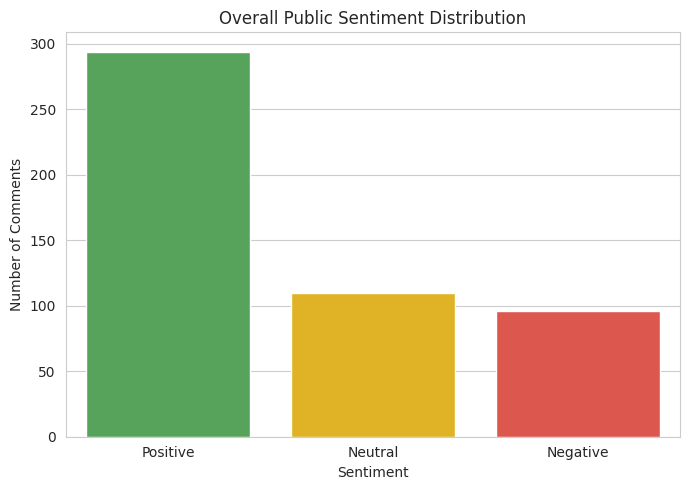

In [9]:
# Overall sentiment distribution
plt.figure(figsize=(7, 5))
order = ['Positive', 'Neutral', 'Negative']
colors = {'Positive': '#4CAF50', 'Neutral': '#FFC107', 'Negative': '#F44336'}
sns.countplot(data=df, x='sentiment', order=order, palette=colors)
plt.title('Overall Public Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=120)
plt.show()


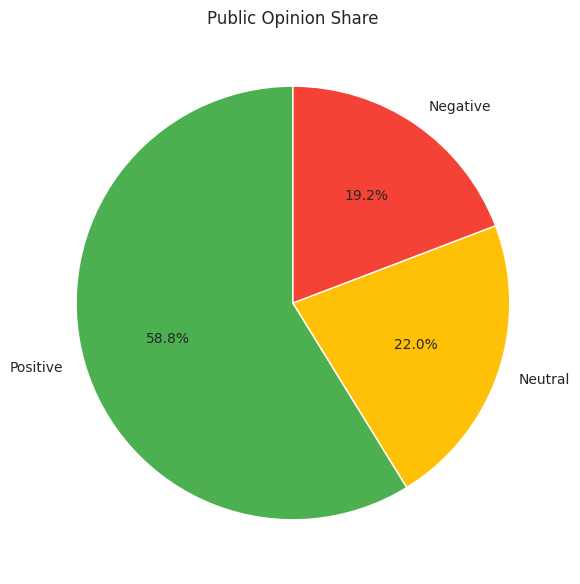

In [10]:
# Sentiment distribution as pie chart
plt.figure(figsize=(6, 6))
sentiment_counts = df['sentiment'].value_counts().reindex(order)
plt.pie(sentiment_counts, labels=sentiment_counts.index,
        autopct='%1.1f%%', colors=[colors[s] for s in sentiment_counts.index],
        startangle=90)
plt.title('Public Opinion Share')
plt.tight_layout()
plt.savefig('sentiment_pie.png', dpi=120)
plt.show()


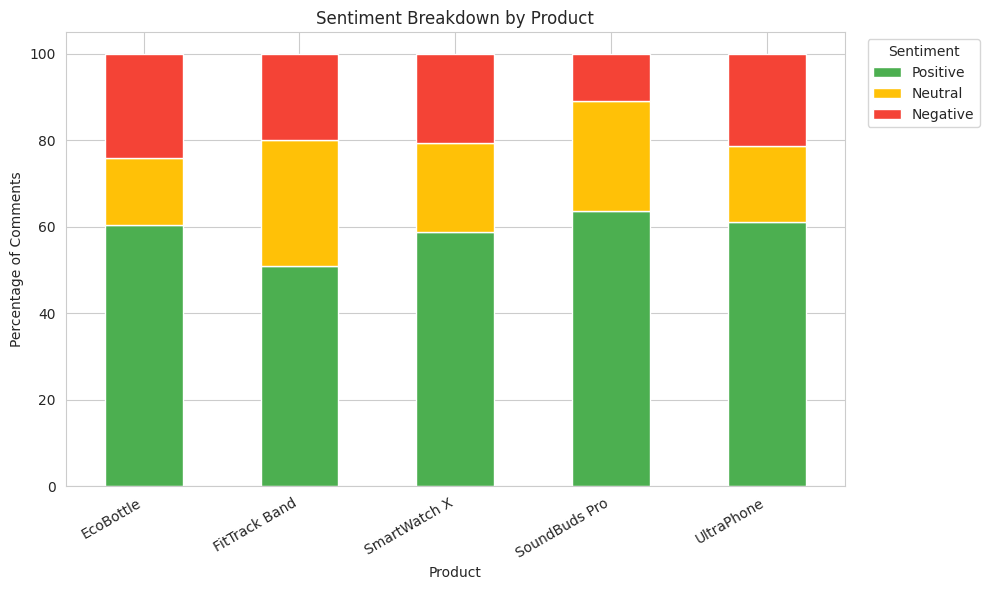

In [11]:
# Sentiment by product (stacked bar)
sentiment_by_product_pct = pd.crosstab(df['product'], df['sentiment'], normalize='index')[order] * 100

sentiment_by_product_pct.plot(kind='bar', stacked=True,
                               color=[colors[s] for s in order], figsize=(10, 6))
plt.title('Sentiment Breakdown by Product')
plt.xlabel('Product')
plt.ylabel('Percentage of Comments')
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sentiment_by_product.png', dpi=120)
plt.show()


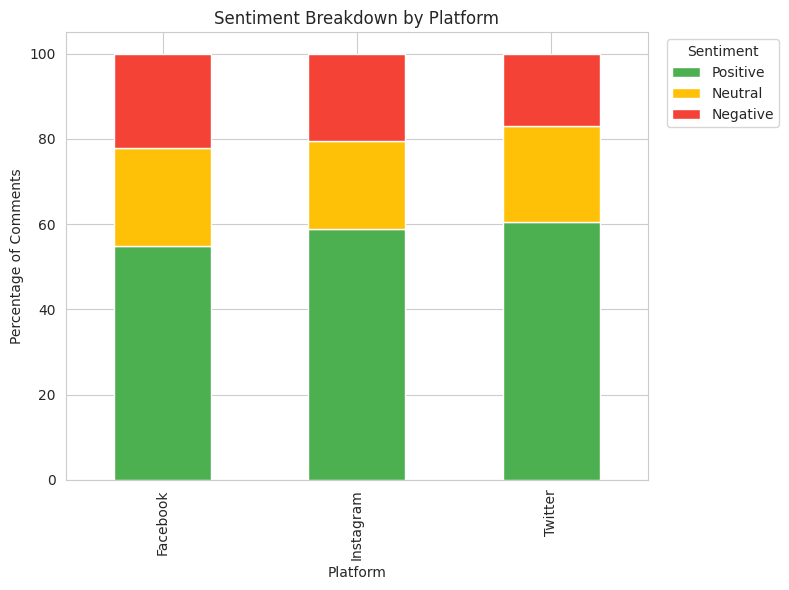

In [12]:
# Sentiment by platform
sentiment_by_platform_pct = pd.crosstab(df['platform'], df['sentiment'], normalize='index')[order] * 100

sentiment_by_platform_pct.plot(kind='bar', stacked=True,
                                color=[colors[s] for s in order], figsize=(8, 6))
plt.title('Sentiment Breakdown by Platform')
plt.xlabel('Platform')
plt.ylabel('Percentage of Comments')
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('sentiment_by_platform.png', dpi=120)
plt.show()


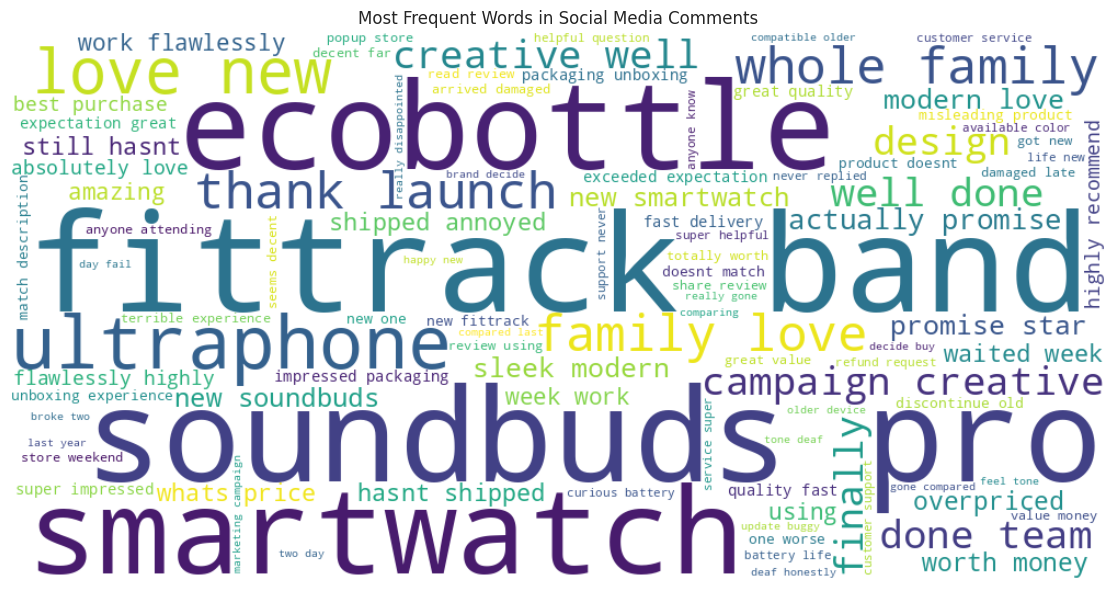

In [13]:
# Word cloud of most frequent terms (trending topics/words)
wc_text = " ".join(all_tokens)
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                       colormap='viridis', max_words=100).generate(wc_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Social Media Comments')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=120)
plt.show()


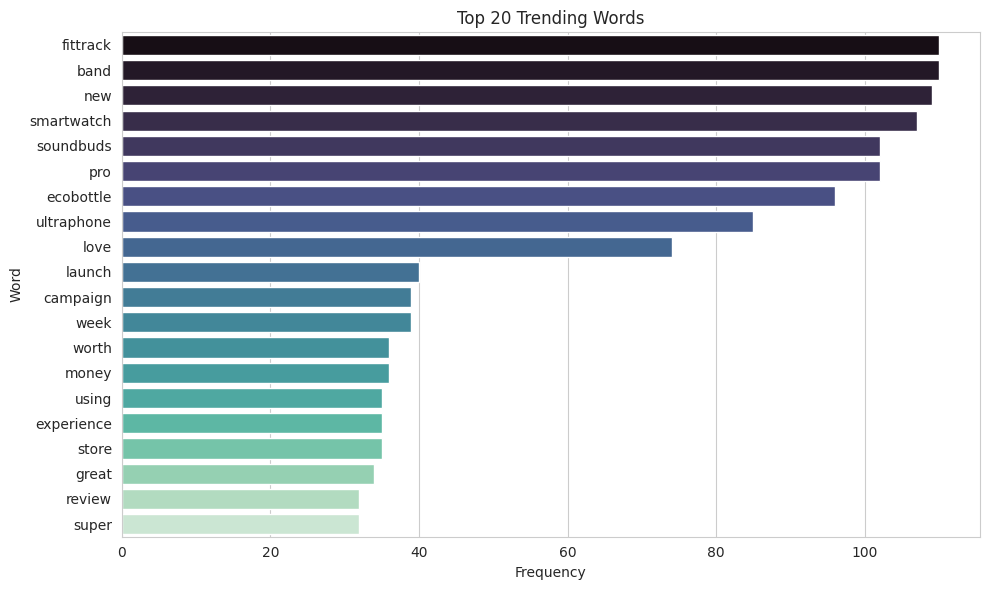

In [14]:
# Top trending words bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_words, x='count', y='word', palette='mako')
plt.title('Top 20 Trending Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('top_words.png', dpi=120)
plt.show()


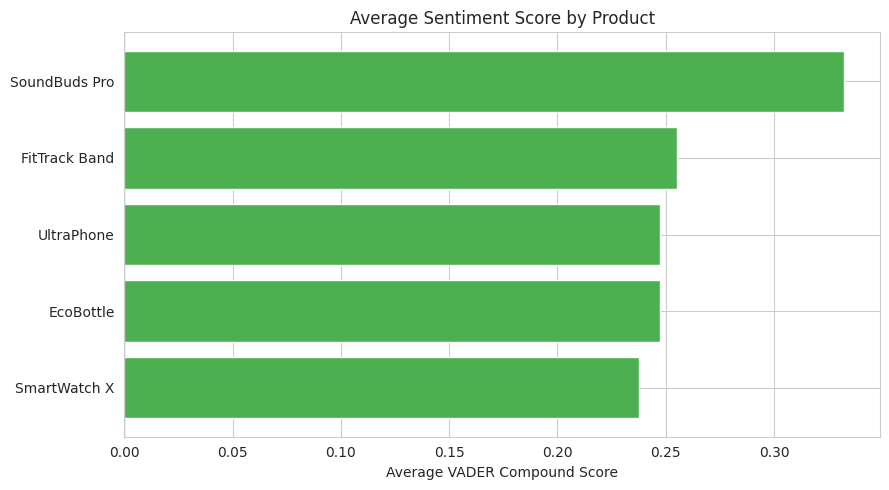

In [15]:
# Average sentiment score by product (gives a sense of overall public opinion strength)
avg_sentiment = df.groupby('product')['sentiment_score'].mean().sort_values()

plt.figure(figsize=(9, 5))
bar_colors = ['#F44336' if v < 0 else '#4CAF50' for v in avg_sentiment.values]
plt.barh(avg_sentiment.index, avg_sentiment.values, color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Average Sentiment Score by Product')
plt.xlabel('Average VADER Compound Score')
plt.tight_layout()
plt.savefig('avg_sentiment_by_product.png', dpi=120)
plt.show()


## Summary / Key Findings

Running this notebook produces:

- **Task 1:** A collected dataset of social media comments (`df`) with platform, product, and comment text.
- **Task 2:** Cleaned and preprocessed text (`clean_comment`, `tokens`, `processed_text` columns), with URLs, mentions, punctuation, stopwords removed and lemmatization applied.
- **Task 3:** Sentiment labels (Positive / Negative / Neutral) and compound scores per comment using VADER, plus breakdowns by platform and product.
- **Task 4:** Trending topics identified via word/hashtag frequency counts and LDA topic modeling.
- **Task 5:** Visualizations — sentiment distribution bar/pie charts, stacked bar charts by product/platform, a word cloud, top trending words, and average sentiment by product — giving a clear picture of overall public opinion.

**Note:** This notebook uses a simulated dataset since live social media API credentials aren't available in this environment. To use with real data, replace the Task 1 cell with your API/scraper output — the rest of the pipeline (Tasks 2–5) will work unchanged as long as the resulting DataFrame has a `comment` column.
